# Model Comparison — Predicting Turbidity from Catchment Features

Fits four regression models — `LinearRegression` (OLS), `Lasso` (L1-regularized OLS),
`RandomForest`, and `XGBoost` — to the same catchment-features CSV and the same
train/test split, then compares their holdout accuracy side by side.

This is a leaner sibling of `linear_regression_turbidity.ipynb` and
`lasso_regression_turbidity.ipynb`: no feature-coefficient/importance breakdown and
no leave-one-out cross-validation — just a head-to-head accuracy comparison across
model families (linear / regularized-linear / bagged-trees / boosted-trees).

---

### Contents

1. Configuration — set `DATA_PATH`, `TARGET_COLUMN`, and per-model hyperparameters here
2. Load & inspect data
3. Train / test split
4. Fit all four models
5. Accuracy comparison — table
6. Accuracy comparison — chart
7. Summary

---

> **Note on sample size:** the default `DATA_PATH` below points at the full
> `scripts/extract_features.py` output for `data/sample_instances`. Rainfall/NDVI/NDWI
> coverage is sparse (most EA samples predate the NIMROD/Sentinel-2 data on disk), so
> after dropping incomplete rows the effective training set is much smaller than the
> raw row count — see section 2's missing-feature counts.

## 1 — Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from eoflow.models.base import split_features_target
from eoflow.models import LinearRegression, Lasso, RandomForest, XGBoost

In [2]:
# ── User-editable settings ───────────────────────────────────────────────────────────────

# Path to the features CSV written by scripts/extract_features.py
DATA_PATH = Path(
    "/home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_full.csv"
)

# Column to predict. `result` holds the measured determinand value for every row
# (its `unit` column records which determinand) — for a CSV that has already been
# filtered to Turbidity samples, this *is* Turbidity.
TARGET_COLUMN = "result"

# Train/test split — shared across every model so accuracy is directly comparable
TEST_SIZE = 0.2
RANDOM_STATE = 0

# Per-model hyperparameters
LINEAR_KWARGS = dict(fit_intercept=True, positive=False)
LASSO_KWARGS = dict(alpha=1.0, fit_intercept=True, positive=False)
RF_KWARGS = dict(n_estimators=300, max_depth=None, random_state=RANDOM_STATE)
XGB_KWARGS = dict(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)

# ──────────────────────────────────────────────────────────────────────

assert DATA_PATH.exists(), f"CSV not found: {DATA_PATH}"

MODEL_COLORS = {
    "LinearRegression": "#3B6FE0",
    "Lasso": "#2E8B7A",
    "RandomForest": "#C4903D",
    "XGBoost": "#C4553D",
}
GRID = "#E4E7ED"

print("Data path     :", DATA_PATH)
print("Target column :", TARGET_COLUMN)

Data path     : /home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_full.csv
Target column : result


## 2 — Load & inspect data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 437 rows × 54 columns


,notation,site_name,date,result,unit,flow_acc_at_pour_point_log,catchment_area_km2,catchment_perimeter_km,catchment_compactness,elevation_mean_m,...,rainfall_max_mm_h,rainfall_total_depth_mm,rainfall_spatial_cv,interaction_bare_x_steep10,interaction_bare_x_steep15,interaction_erodible_x_bare,interaction_wet_x_steep10,interaction_rain_x_bare,interaction_spr_x_bare,interaction_slope_mean_x_inv_ndvi
0,SW-70220104,RIVER AXE AT AXE BRIDGE BELOW COLYTON & COLYFO...,2022-04-06,3.6,NEPHELOMETRIC TURBIDITY UNITS,12.235981,124.311999,81.546100,0.234918,114.887733,...,26.0,4.913725,4.117858,0.000436,0.000077,0.000701,0.000001,0.000168,0.165021,1.906083
1,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2010-01-05,3.6,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2010-09-28,3.0,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2011-06-06,2.5,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2012-02-15,3.6,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
assert TARGET_COLUMN in df.columns, f"{TARGET_COLUMN!r} not in columns: {list(df.columns)}"

if "unit" in df.columns:
    print("Determinand unit(s) present:")
    print(df["unit"].value_counts())

print(f"\n{TARGET_COLUMN} summary:")
df[TARGET_COLUMN].describe()

Determinand unit(s) present:
unit
NEPHELOMETRIC TURBIDITY UNITS    437
Name: count, dtype: int64

result summary:


count     396.000000
mean       41.793333
std       499.312932
min         1.000000
25%         2.500000
50%         5.000000
75%        13.275000
max      9920.000000
Name: result, dtype: float64

In [5]:
# Split into predictors X and target y. This drops the identity columns
# (notation, site_name, date, result, unit) and keeps every other numeric column.
X, y = split_features_target(df, target_column=TARGET_COLUMN)

n_missing = X.isna().any(axis=1).sum()
print(f"Features: {X.shape[1]} columns")
print(f"Rows with at least one missing feature: {n_missing}/{len(X)}")
print(f"Rows with missing target: {y.isna().sum()}/{len(y)}")

Features: 49 columns
Rows with at least one missing feature: 381/437
Rows with missing target: 41/437


In [6]:
# Drop rows with a missing target or any missing feature. Each model's `fit` would
# silently drop NaN rows on its own, but `score`/`predict` do not — leaving NaNs in
# the test split would poison the holdout R² / RMSE / MAE with NaN, and different
# models could otherwise end up scored on different rows. Cleaning once, upfront,
# keeps every model in this comparison on the exact same data.
complete_mask = X.notna().all(axis=1) & y.notna()
n_dropped = int((~complete_mask).sum())
print(f"Dropping {n_dropped}/{len(X)} rows with missing target or feature values.")

X, y = X.loc[complete_mask].reset_index(drop=True), y.loc[complete_mask].reset_index(drop=True)
print(f"Remaining: {len(X)} rows")

Dropping 384/437 rows with missing target or feature values.
Remaining: 53 rows


## 3 — Train / test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")

if len(X_test) < 3:
    print("\nWarning: very few holdout rows — accuracy below will be noisy.")

Train: 42 rows   Test: 11 rows


## 4 — Fit all four models

In [8]:
models = {
    "LinearRegression": LinearRegression(**LINEAR_KWARGS),
    "Lasso": Lasso(**LASSO_KWARGS),
    "RandomForest": RandomForest(**RF_KWARGS),
    "XGBoost": XGBoost(**XGB_KWARGS),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:<18} fitted on {len(X_train)} rows × {len(model.feature_names_)} features")

2026-07-23 12:51:09,761 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 42 rows × 49 features.


LinearRegression   fitted on 42 rows × 49 features
2026-07-23 12:51:09,764 - eoflow.models.Lasso - INFO - Fit Lasso on 42 rows × 49 features (16/49 coefficients non-zero, alpha=1).


Lasso              fitted on 42 rows × 49 features


2026-07-23 12:51:10,034 - eoflow.models.RandomForest - INFO - Fit RandomForest on 42 rows × 49 features.


RandomForest       fitted on 42 rows × 49 features
2026-07-23 12:51:10,172 - eoflow.models.XGBoost - INFO - Fit XGBoost on 42 rows × 49 features.


XGBoost            fitted on 42 rows × 49 features


## 5 — Accuracy comparison — table

In [9]:
rows = []
for name, model in models.items():
    train_metrics = model.score(X_train, y_train)
    test_metrics = model.score(X_test, y_test)
    rows.append({"model": name, "split": "train", **train_metrics})
    rows.append({"model": name, "split": "test", **test_metrics})

metrics_df = pd.DataFrame(rows).set_index(["model", "split"])
metrics_df.round(4)

r2     rmse      mae
model            split                          
LinearRegression train  1.0000   0.0653   0.0153
                 test  -6.9251  43.1933  32.6665
Lasso            train  0.5845  11.7291   7.6033
                 test  -0.8760  21.0152  16.7342
RandomForest     train  0.8515   7.0120   3.6600
                 test   0.6085   9.6000   7.7038
XGBoost          train  1.0000   0.0194   0.0146
                 test   0.0437  15.0038   9.9767

## 6 — Accuracy comparison — chart

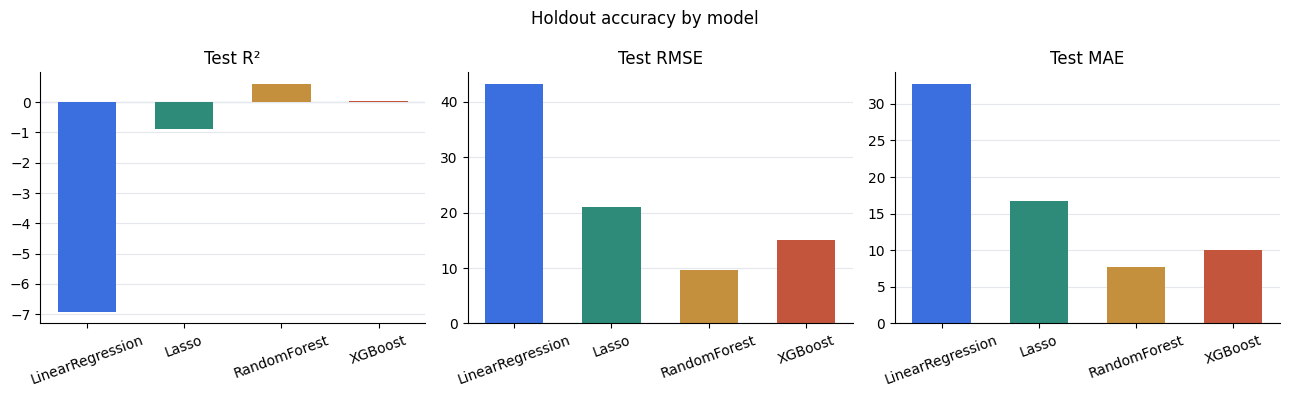

In [10]:
test_df = metrics_df.xs("test", level="split")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, title in zip(
    axes, ["r2", "rmse", "mae"], ["Test R²", "Test RMSE", "Test MAE"]
):
    colors = [MODEL_COLORS[m] for m in test_df.index]
    ax.bar(test_df.index, test_df[metric], color=colors, width=0.6)
    ax.set_title(title)
    ax.axhline(0, color=GRID, lw=1, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Holdout accuracy by model")
fig.tight_layout()
plt.show()

## 7 — Summary

In [11]:
best_model = test_df["r2"].idxmax()

print(f"Dataset  : {DATA_PATH.name}  ({len(df)} rows, {len(X)} complete rows used)")
print(f"Target   : {TARGET_COLUMN}")
print(f"Train/test: {len(X_train)}/{len(X_test)} rows")
print()
print("Accuracy (R² / RMSE / MAE) by model and split:")
print(metrics_df.round(4).to_string())
print()
print(f"Best test R²: {best_model} ({test_df.loc[best_model, 'r2']:.4f})")
print()
print(
    "Note: with only a few dozen complete-data rows, these results are illustrative — "
    "re-run against a larger extract_features.py output (wider NIMROD/EO coverage) for "
    "a meaningful comparison. Tree ensembles (RandomForest/XGBoost) and OLS can overfit "
    "hard at this sample size; Lasso's regularization and RandomForest's bagging tend to "
    "generalize more conservatively than plain OLS or a deep, lightly-regularized XGBoost."
)

Dataset  : catchment_features_full.csv  (437 rows, 53 complete rows used)
Target   : result
Train/test: 42/11 rows

Accuracy (R² / RMSE / MAE) by model and split:
                            r2     rmse      mae
model            split                          
LinearRegression train  1.0000   0.0653   0.0153
                 test  -6.9251  43.1933  32.6665
Lasso            train  0.5845  11.7291   7.6033
                 test  -0.8760  21.0152  16.7342
RandomForest     train  0.8515   7.0120   3.6600
                 test   0.6085   9.6000   7.7038
XGBoost          train  1.0000   0.0194   0.0146
                 test   0.0437  15.0038   9.9767

Best test R²: RandomForest (0.6085)

Note: with only a few dozen complete-data rows, these results are illustrative — re-run against a larger extract_features.py output (wider NIMROD/EO coverage) for a meaningful comparison. Tree ensembles (RandomForest/XGBoost) and OLS can overfit hard at this sample size; Lasso's regularization and RandomFore